# Recurrent Neural Net

In this notebook I will demonstrate how a Recurrent Neural Net (RNN) can be used to predict time series data very accurately.

### Import

As always we begin by importing all the required libraries.

In [16]:
%matplotlib inline

from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf
import os

In [17]:
csv_path = "./data/epidemic_process_raw_data.csv"
df = pd.read_csv(csv_path)
df.head(4)

,1,2,3,4,5,6,7,8,9,10,...,492,493,494,495,496,497,498,499,500,501
0,100.287149,103.541223,95.879814,96.354848,96.980932,97.855310,98.940537,100.187494,98.265709,95.307794,...,4.925236,4.922108,4.918981,4.915853,4.912726,4.950240,4.995291,5.040342,5.085393,5.130445
1,0.993774,1.017558,1.070030,1.116168,1.142078,1.134735,1.182418,1.272310,1.356565,1.438978,...,0.391775,0.384359,0.376942,0.369526,0.362109,0.356669,0.351595,0.346521,0.341447,0.336374
2,0.000000,0.017741,0.036585,0.054735,0.074266,0.096065,0.117691,0.139184,0.163615,0.189006,...,97.247764,96.062916,94.878068,93.693219,92.508371,92.617122,92.965783,93.314443,93.663103,94.011764
3,0.000000,0.000178,0.000364,0.000562,0.000757,0.000947,0.001160,0.001389,0.001635,0.001887,...,0.947347,0.950713,0.954079,0.957445,0.960811,0.959320,0.956929,0.954537,0.952146,0.949755


In [18]:

dfSusceptible = df[df.index % 4 == 0]
dfInfected = df[df.index % 4 == 1]
dfRecovered = df[df.index % 4 == 2]
dfDead = df[df.index % 4 == 3]
dfInfected.head()

,1,2,3,4,5,6,7,8,9,10,...,492,493,494,495,496,497,498,499,500,501
1,0.993774,1.017558,1.070030,1.116168,1.142078,1.134735,1.182418,1.272310,1.356565,1.438978,...,0.391775,0.384359,0.376942,0.369526,0.362109,0.356669,0.351595,0.346521,0.341447,0.336374
5,1.021677,1.045410,1.120324,1.175914,1.236878,1.306676,1.387931,1.477973,1.549873,1.615840,...,0.172933,0.171653,0.169739,0.167366,0.164993,0.162620,0.160247,0.157874,0.155501,0.153128
9,1.020043,1.011238,1.031122,1.048642,1.049479,1.022891,1.035862,1.079177,1.114531,1.147282,...,5.658505,5.625406,5.592308,5.559209,5.526111,5.493012,5.459914,5.426815,5.393717,5.360619
13,1.035248,1.014189,1.133178,1.135622,1.157984,1.213088,1.281406,1.359858,1.423234,1.481680,...,0.297238,0.292756,0.288433,0.284145,0.279857,0.275569,0.271280,0.266992,0.262704,0.258416
17,1.012666,1.016949,1.053194,1.097599,1.143640,1.192369,1.238880,1.283688,1.324305,1.363552,...,0.475822,0.467301,0.458779,0.450518,0.444609,0.438701,0.432715,0.425247,0.417780,0.410313


### Controll

We check three of the simulations to make sure the data seems correct.

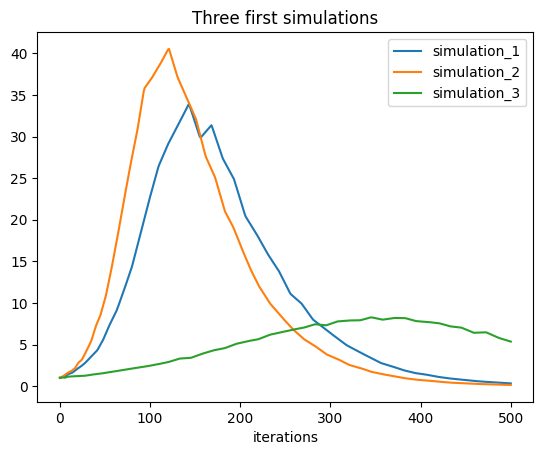

In [19]:
# Plot three of the simulations
fig, ax = plt.subplots()

ax.plot(range(dfInfected.shape[1]), dfInfected.loc[1,:], label="simulation_1")
ax.plot(range(dfInfected.shape[1]), dfInfected.loc[5,:], label="simulation_2")
ax.plot(range(dfInfected.shape[1]), dfInfected.loc[9,:], label="simulation_3")

ax.set_title("Three first simulations")
ax.set_xlabel("iterations")
ax.set_ylabel("")
ax.legend()

plt.show()

### Normalizing

We normalize and split the data to prepare it for training and testing.

In [20]:
dfInfected_arr = dfInfected.values
dfInfected_arr.shape
TRAIN_SPLIT = int(dfInfected_arr.shape[0]-dfInfected_arr.shape[0]*0.1)
print(TRAIN_SPLIT)

uni_train_mean = dfInfected_arr[:TRAIN_SPLIT].mean()
uni_train_std = dfInfected_arr[:TRAIN_SPLIT].std()
uni_data = (dfInfected_arr-uni_train_mean)/uni_train_std
print ('\nUnivariate data shape')
print(uni_data.shape)

135

Univariate data shape
(150, 501)


## Creating a TimeSeries

We now need to create a TimeSeries to use later on.

In [21]:
def time_series(dataset: np.ndarray, start_series: int, end_series: int, history_size: int = 20, target_size: int = 1) -> tuple[np.ndarray, np.ndarray]:
    '''
    Creates TimeSeries of sequential data to use with RNN training and predicting.
    
    Args:
        dataset: the data to create TimeSeries from
        start_series: index for the first entry
        end_series: index for the last entry
        history_size: number of past data to use in prediction
        target_size: amount of predictions to perform
    
    Returns:
        time_series, actual_values
    '''

    series = []
    actual_values = []

    start_index = history_size
    end_index = dataset.shape[1] - target_size

    for c in range(start_series, end_series):
        for i in range(start_index, end_index):
            indices = np.arange(i - history_size, i)
            series.append(dataset[c][indices].reshape((history_size, 1)))
            actual_values.append(dataset[c][i + target_size])
    
    return np.array(series), np.array(actual_values)


In [22]:
univariate_past_history = 20 # Days
univariate_future_target = 0 # Current day

x_train_uni, y_train_uni = time_series(uni_data, 0, TRAIN_SPLIT,
                                           univariate_past_history,
                                           univariate_future_target)
x_val_uni, y_val_uni = time_series(uni_data, TRAIN_SPLIT, len(uni_data),
                                       univariate_past_history,
                                       univariate_future_target)

In [23]:
print ('Single window of past history')
print (x_train_uni[0])
print ('\n Target number to predict')
print (y_train_uni[0])
print ('\n Number of traing data points')
print (y_train_uni.shape[0])
print ('\n Number of test data points')
print (x_val_uni.shape[0])

Single window of past history
[[-0.95291296]
 [-0.95044298]
 [-0.94499366]
 [-0.9402021 ]
 [-0.93751136]
 [-0.93827393]
 [-0.93332191]
 [-0.92398652]
 [-0.91523643]
 [-0.90667772]
 [-0.90243571]
 [-0.89846308]
 [-0.89449045]
 [-0.89051782]
 [-0.88593997]
 [-0.87701137]
 [-0.86808277]
 [-0.85915417]
 [-0.85022557]
 [-0.84167481]]

 Target number to predict
-0.8339932964893617

 Number of traing data points
64935

 Number of test data points
7215


In [24]:
def create_time_steps(length):
    return [i for i in range(-length, 0)]

def show_plot(plot_data: np.ndarray, delta: float, title: str):
    labels = ['History', 'True Future', 'Model Prediction']
    marker = ['.-', 'rx', 'go']
    time_steps = create_time_steps(plot_data[0].shape[0])

    fig, ax = plt.subplots()
    if delta:
        future = delta
    else:
        future = 0
    ax.set_title(title)
    for i, x in enumerate(plot_data):
        if i:
            ax.plot(future, plot_data[i], marker[i], markersize=10,label=labels[i])
        else:
            ax.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])
    ax.legend()
    ax.set_xlim([time_steps[0], (future+5)*2])
    ax.set_xlabel('Time-Step')
    return fig, ax

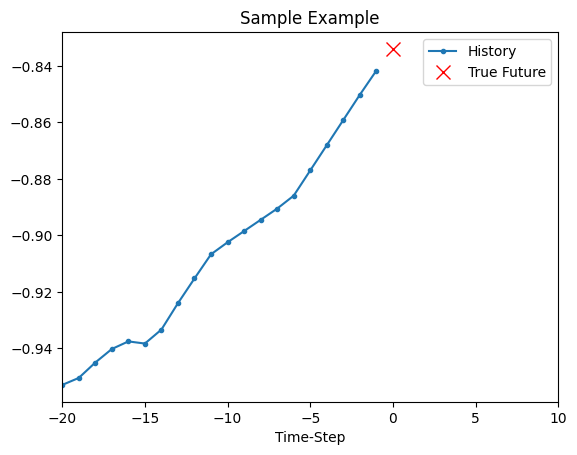

In [25]:
fig, ax = show_plot([x_train_uni[0], y_train_uni[0]], 0, 'Sample Example')
plt.show()

### Baseline Forecasting

To get a baseline we simply predict the mean of the history.

In [26]:

def baseline(history):
    return np.mean(history)

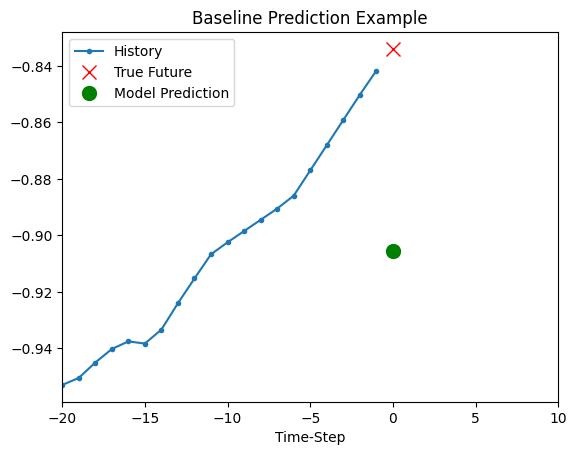

In [27]:
fig, ax = show_plot([x_train_uni[0], y_train_uni[0], baseline(x_train_uni[0])], 0, 'Baseline Prediction Example')
plt.show()

Not a very good guess in this case.

### Normalized LSTM based Forecasting

Now we implement a LSTM model and use it to predict the next value.

In [28]:
print (x_train_uni.shape)
print (y_train_uni.shape)
x_train_uni.dtype

(64935, 20, 1)
(64935,)


dtype('float64')

In [29]:
BATCH_SIZE = 256
BUFFER_SIZE = 10000

train_univariate = tf.data.Dataset.from_tensor_slices((x_train_uni, y_train_uni))
train_univariate = train_univariate.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()

val_univariate = tf.data.Dataset.from_tensor_slices((x_val_uni, y_val_uni))
val_univariate = val_univariate.batch(BATCH_SIZE).repeat()

print(train_univariate)

<_RepeatDataset element_spec=(TensorSpec(shape=(None, 20, 1), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>


## Initiating the LSTM model

In [31]:
simple_lstm_model = tf.keras.models.Sequential([
    tf.keras.layers.LSTM(8, input_shape=x_train_uni.shape[-2:]),
    tf.keras.layers.Dense(1)
])

simple_lstm_model.compile(optimizer='adam', loss='mae')
simple_lstm_model.summary()
print(x_train_uni.shape[-2:])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 8)              │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 329 (1.29 KB)

 Trainable params: 329 (1.29 KB)

 Non-trainable params: 0 (0.00 B)

(20, 1)
